# Heart Disease Classification

## Project Overview

The goal of this project is to build machine learning models capable of predicting whether a patient has heart disease based on demographic, clinical, and diagnostic measurements collected during cardiovascular examinations.

Two fundamentally different classification approaches will be explored and compared:

* Logistic Regression
* K-Nearest Neighbors (KNN)

The purpose of this project is not only to build accurate classifiers, but also to understand how different machine learning algorithms approach the same prediction problem and why they may produce different results.

For this project, the target variable will contain two classes:

* 0 = No Heart Disease
* 1 = Heart Disease

## Why Compare Logistic Regression and KNN?

Although both models solve the same classification task, they do so in very different ways.

* Logistic Regression learns a mathematical relationship between features and the target.
* KNN makes predictions by finding the most similar observations in the training data.

Comparing these models on the same dataset provides an opportunity to understand:

* Model-based learning vs distance-based learning
* The impact of feature scaling
* Hyperparameter tuning through K selection
* Classification model evaluation
* How different algorithms behave on the same problem

## Project Workflow

1. Load and inspect the dataset
2. Visualize the data and perform exploratory data analysis (EDA)
3. Clean and preprocess the data
4. Split the dataset into training and testing sets
5. Apply preprocessing to training and testing data
6. Train Logistic Regression and KNN models
7. Evaluate and compare model performance
8. Generate predictions on unseen samples
9. Analyze results and draw conclusions

## Learning Goals

This project is designed to strengthen practical machine learning skills by focusing on:

* Understanding how the K-Nearest Neighbors algorithm works
* Reinforcing Logistic Regression concepts through comparison
* Comparing distance-based learning with model-based learning
* Understanding the importance of feature scaling and its impact on KNN performance
* Exploring the effect of different K values on model behavior
* Practicing classification model evaluation using accuracy, precision, recall, F1-score, and confusion matrices
* Learning how to compare machine learning models fairly on the same dataset
* Building intuition about why different algorithms produce different results
* Developing a structured workflow for EDA, preprocessing, model training, and evaluation

## Dataset Information

The dataset contains 920 patient records collected from multiple international cardiovascular research centers and hospitals.

Features include patient demographics, chest pain characteristics, blood pressure measurements, cholesterol levels, electrocardiographic results, exercise test outcomes, and other clinical indicators commonly used in the diagnosis of heart disease.

The original target variable contains five classes:

* 0 = No Heart Disease
* 1 = Heart Disease (Level 1)
* 2 = Heart Disease (Level 2)
* 3 = Heart Disease (Level 3)
* 4 = Heart Disease (Level 4)

For this project, the target will be converted into a binary classification problem:

* 0 = No Heart Disease
* 1 = Heart Disease

## Technologies

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* Jupyter Notebook


## 1. Load Dataset

In [83]:
import pandas as pd

In [84]:
df = pd.read_csv("heart_disease_uci.csv")
df.columns = df.columns.str.strip() # Strip leading and trailing spaces from all column names

In [85]:
df = pd.read_csv("heart_disease_uci.csv")

df = df.rename(columns={
    "cp": "Chest Pain Type",
    "trestbps": "Resting Blood Pressure",
    "chol": "Cholesterol",
    "thalch": "Max Heart Rate",
    "exang": "Exercise Angina",
    "num": "Heart Disease Status"
})

## 2. Show Dataset Details

In [86]:
df.head()

,id,age,sex,dataset,Chest Pain Type,Resting Blood Pressure,Cholesterol,fbs,restecg,Max Heart Rate,Exercise Angina,oldpeak,slope,ca,thal,Heart Disease Status
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      920 non-null    int64  
 1   age                     920 non-null    int64  
 2   sex                     920 non-null    str    
 3   dataset                 920 non-null    str    
 4   Chest Pain Type         920 non-null    str    
 5   Resting Blood Pressure  861 non-null    float64
 6   Cholesterol             890 non-null    float64
 7   fbs                     830 non-null    object 
 8   restecg                 918 non-null    str    
 9   Max Heart Rate          865 non-null    float64
 10  Exercise Angina         865 non-null    object 
 11  oldpeak                 858 non-null    float64
 12  slope                   611 non-null    str    
 13  ca                      309 non-null    float64
 14  thal                    434 non-null    str    
 15  

In [88]:
df.describe()

,id,age,Resting Blood Pressure,Cholesterol,Max Heart Rate,oldpeak,ca,Heart Disease Status
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### Reference Guide for Dataset Features

**Age**
- Adult: 18–64 years
- Older Adult: 65+ years

**Resting Blood Pressure (`trestbps`)**
- Normal: Below 120 mm Hg
- Elevated: 120–129 mm Hg
- High: 130+ mm Hg

**Serum Cholesterol (`chol`)**
- Desirable: Below 200 mg/dL
- Borderline High: 200–239 mg/dL
- High: 240+ mg/dL

**Fasting Blood Sugar (`fbs`)**
- 0 = Fasting blood sugar ≤ 120 mg/dL
- 1 = Fasting blood sugar > 120 mg/dL

**Maximum Heart Rate (`thalch`)**
- Higher values generally indicate better exercise response.
- Lower values may be associated with reduced cardiovascular fitness or cardiac issues.

**Exercise-Induced Angina (`exang`)**
- 0 = No
- 1 = Yes

**Oldpeak**
- ST depression induced by exercise relative to rest.
- Higher values may indicate greater abnormality during exercise testing.

**Number of Major Vessels (`ca`)**
- Ranges from 0 to 3 in the original description.
- Higher values may indicate more vessels affected.

**Target (`num`)**
- 0 = No heart disease
- 1–4 = Presence/severity of heart disease

## 3. Data Visualization & Exploratory Data Analysis (EDA)

In [89]:
import matplotlib.pyplot as plt

In [90]:
for col in df.columns:
    print(col)

id
age
sex
dataset
Chest Pain Type
Resting Blood Pressure
Cholesterol
fbs
restecg
Max Heart Rate
Exercise Angina
oldpeak
slope
ca
thal
Heart Disease Status


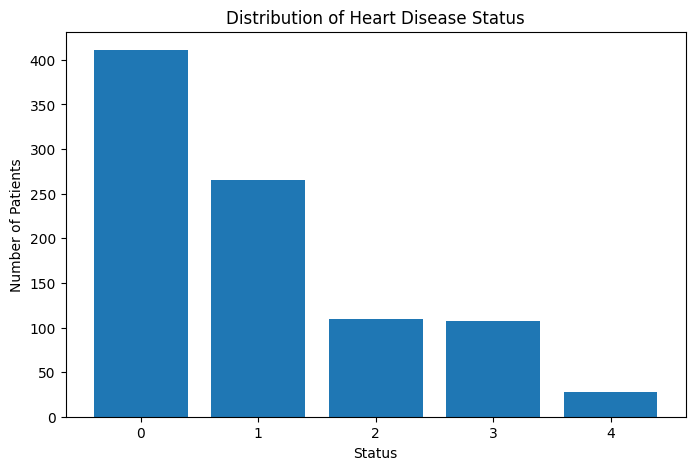

In [94]:
status_counts = df["Heart Disease Status"].value_counts()
# Status:
# No    8000
# Yes      2000

plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values)
# status_counts.index
# Index([0,1,2,3,4])

# status_counts.values
# array([411 265 109 107  28])

plt.title("Distribution of Heart Disease Status")
plt.xlabel("Status")
plt.ylabel("Number of Patients")

plt.show()

### Observations

- Most patients are either labeled as having no heart disease or a lower disease severity level.
- Higher severity classes are much less frequent.
- The original target column is multi-class, where 0 means no heart disease and values 1–4 represent different levels of heart disease presence/severity.

### Potential Actions

- Convert the target into a binary classification problem:
  - 0 = No Heart Disease
  - 1 = Heart Disease
- Use the binary target for Logistic Regression and KNN classification.

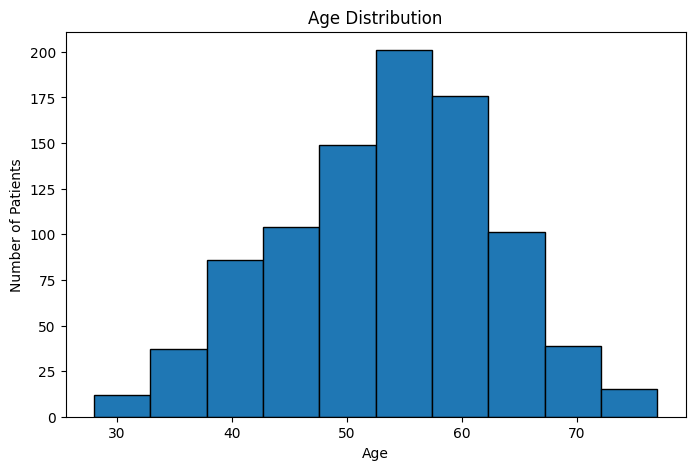

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=10, edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")   
plt.ylabel("Number of Patients")

plt.show()

### Observations

- The age distribution is approximately bell-shaped and centered around middle-aged adults.
- Most patients are between 45 and 65 years old.
- Very young and very old patients are less common in the dataset.
- The distribution appears realistic for a cardiovascular disease study, as middle-aged and older adults are more likely to undergo cardiac evaluation.

### Potential Actions

- Investigate whether heart disease prevalence increases with age.
- Compare age distributions between patients with and without heart disease.
- Retain age as an important predictive feature for model training.